In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print("Training data shape:", df_train.shape)
print("Test data shape:", df_test.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print("Training data shape:", df_train.shape)
print("Test data shape:", df_test.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [1]:
import os
print(os.getcwd())

C:\Users\Matthew\anaconda_projects\d3e82e17-d9c4-42ff-b303-dba8a2f4006d


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print("Training data shape:", df_train.shape)
print("Test data shape:", df_test.shape)

Training data shape: (1460, 81)
Test data shape: (1459, 80)


In [4]:
print(df_train.head())
print("\n")
print(df_train.info())
print("\n")
print(df_train.describe())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [5]:
missing_values = df_train.isnull().sum()
missing_percent = (df_train.isnull().sum() / len(df_train)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_values, 'Percent': missing_percent})
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

              Missing_Count    Percent
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageType               81   5.547945
GarageYrBlt              81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
GarageCond               81   5.547945
BsmtFinType2             38   2.602740
BsmtExposure             38   2.602740
BsmtFinType1             37   2.534247
BsmtCond                 37   2.534247
BsmtQual                 37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


In [6]:
# Stage 2: Data Cleaning

# Drop columns with too many missing values (>50%)
df_train = df_train.drop(['PoolQC', 'MiscFeature', 'Alley', 'Fence'], axis=1)
df_test = df_test.drop(['PoolQC', 'MiscFeature', 'Alley', 'Fence'], axis=1)

# Fill remaining missing values
# For numeric columns: fill with median
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    if df_train[col].isnull().sum() > 0:
        median_val = df_train[col].median()
        df_train[col].fillna(median_val, inplace=True)
        df_test[col].fillna(median_val, inplace=True)

# For categorical columns: fill with mode (most common value)
categorical_cols = df_train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_train[col].isnull().sum() > 0:
        mode_val = df_train[col].mode()[0]
        df_train[col].fillna(mode_val, inplace=True)
        df_test[col].fillna(mode_val, inplace=True)

# Verify no missing values remain
print("Missing values after cleaning:")
print(df_train.isnull().sum().sum())
print(df_test.isnull().sum().sum())

print("\nTrain shape:", df_train.shape)
print("Test shape:", df_test.shape)

Missing values after cleaning:
0
22

Train shape: (1460, 77)
Test shape: (1459, 76)


C:\Users\Matthew\AppData\Local\Temp\ipykernel_18688\2979710461.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train[col].fillna(median_val, inplace=True)
C:\Users\Matthew\AppData\Local\Temp\ipykernel_18688\2979710461.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [7]:
# Stage 3: Prepare data for machine learning

# Separate features (X) and target (y)
X_train = df_train.drop(['SalePrice', 'Id'], axis=1)
y_train = df_train['SalePrice']

X_test = df_test.drop(['Id'], axis=1)

# Convert categorical columns to numeric using one-hot encoding
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Make sure X_train and X_test have the same columns
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0

X_test = X_test[X_train.columns]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1460, 274)
X_test shape: (1459, 274)
y_train shape: (1460,)


In [8]:
# Stage 4: Train the model

# Split training data into train and validation sets (80/20 split)
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_split, y_train_split)

# Make predictions on validation set
y_pred_val = model.predict(X_val)

# Make predictions on test set (for submission)
y_pred_test = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_val, y_pred_val)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred_val)

print("Model Performance:")
print(f"RMSE (Root Mean Squared Error): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"\nWhat this means:")
print(f"- RMSE: On average, predictions are off by ${rmse:,.2f}")
print(f"- R² Score: The model explains {r2*100:.2f}% of the price variation")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [9]:
# Fill remaining missing values in X_test
for col in X_test.columns:
    if X_test[col].isnull().sum() > 0:
        median_val = X_train[col].median()
        X_test[col].fillna(median_val, inplace=True)

print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_test: 0


C:\Users\Matthew\AppData\Local\Temp\ipykernel_18688\2221807467.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test[col].fillna(median_val, inplace=True)


In [10]:
# Stage 4: Train the model

# Split training data into train and validation sets (80/20 split)
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_split, y_train_split)

# Make predictions on validation set
y_pred_val = model.predict(X_val)

# Make predictions on test set (for submission)
y_pred_test = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_val, y_pred_val)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred_val)

print("Model Performance:")
print(f"RMSE (Root Mean Squared Error): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"\nWhat this means:")
print(f"- RMSE: On average, predictions are off by ${rmse:,.2f}")
print(f"- R² Score: The model explains {r2*100:.2f}% of the price variation")

Model Performance:
RMSE (Root Mean Squared Error): $29,773.44
R² Score: 0.8844

What this means:
- RMSE: On average, predictions are off by $29,773.44
- R² Score: The model explains 88.44% of the price variation


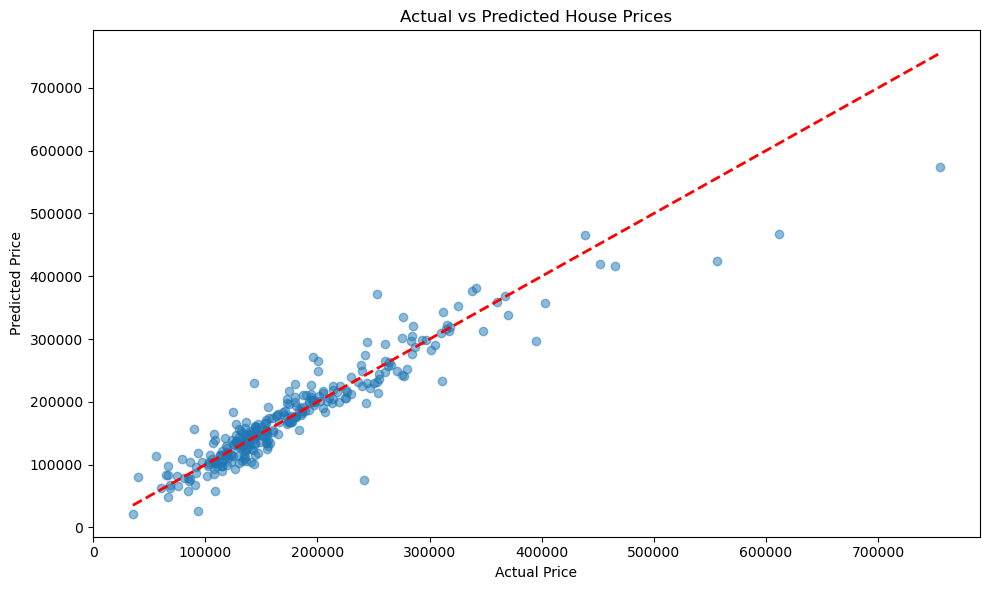

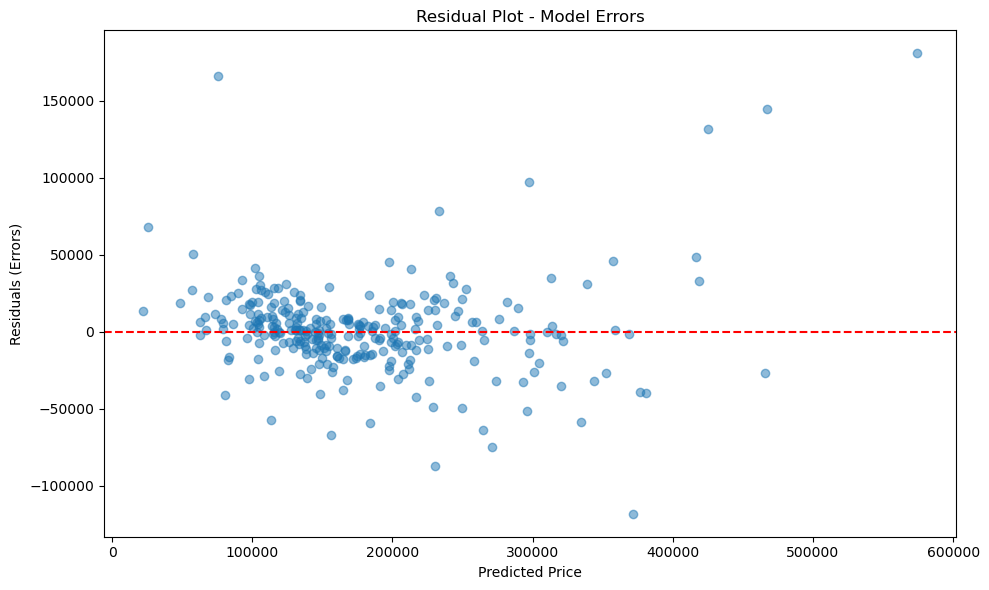

Visualisations saved!


In [11]:
# Stage 5: Visualise the results

# Create a comparison of actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred_val, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

# Residuals plot (prediction errors)
residuals = y_val - y_pred_val
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_val, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot - Model Errors')
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=150)
plt.show()

print("Visualisations saved!")

In [12]:
# Export cleaned data
df_train.to_csv('house_prices_cleaned.csv', index=False)
print("Cleaned training data saved!")

# Create submission file with predictions
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': y_pred_test
})
submission.to_csv('house_prices_predictions.csv', index=False)
print("Predictions saved!")

Cleaned training data saved!
Predictions saved!
